In [23]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Combined Trend Strategy

## Hypothesis
We are testing a combination of 3 strategies.
1. Trend Following
2. Split Trend Following
3. Vol Reduction

### 1. Trend Following
We theorize the existence of trend / momentum premium, where we can obtain better risk-adjusted returns by going long the asset when recent returns are positive and going short the asset when recent returns are negative.

The momentum premium is well-documented in literature, even though the source of the premium is still being debated.

### 2. Split Trend Following
We note that the trend following strategy has a key parameter, which is the lookback period for which we calculate the recent returns. The optimal value of this parameter is dependent on market conditions. Attempting to optimize this parameter based on historical backtesting likely leads to over-fitting.

We propose to adjust our position based on multiple lookback periods as a weighted-sum of the signals suggested by each lookback period.

### 3. Vol Reduction
We propose to reduce the volatility of returns by reducing position during volatile periods. Using recent volatility and VIX-measures as a proxy for forward volatility, we can compute the forward variance and use it to adjust our position, reducing our exposure when forward volatility is high. This should help us to reduce our exposure during volatile economic periods and lead to better risk-adjusted returns.

## Import Libraries

In [24]:
import pandas as pd
import numpy as np
from utils.backtester import BackTester
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from utils.data_fetcher import YahooDataFetcher, TickerPriceDataFetcher
import datetime
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit
import lightgbm as lgb
import optuna
from indicators.returns import calculate_binary_forward_returns, calculate_binary_returns, calculate_binary_MA_returns, calculate_forward_returns, calculate_returns, calculate_MA_returns
from indicators.breakout import calculate_breakout
from indicators.volatility import calculate_atr, calculate_forward_vol
from indicators.volume import calculate_rel_volume
from indicators.trend import calculate_r2
import backtrader as bt
from strategies.base import BaseStrategy
import os
import numpy as np
from sklearn.preprocessing import MinMaxScaler

## Utility Functions

In [25]:
def load_data(data):
    
    fetcher = TickerPriceDataFetcher()  
    asset_list = data['asset_list']
    ticker_list = asset_list + [data[ticker]['vol_measure'] for ticker in data['asset_list']]
    ticker_list.append('SHV')
    price_data = fetcher.load_data(ticker_list=ticker_list)
    
    for ticker in asset_list:
        vol_ticker = data[ticker]['vol_measure']
        df = price_data[ticker].copy()
        df_vol = price_data.get(vol_ticker)
        if df_vol is None:
            print(f'{vol_ticker} not found')
        else:
            df['vix'] = df_vol['close'].copy()
        data[ticker]['data'] = df.copy()

    ticker = 'SHV'
    data[ticker]['data'] = price_data[ticker].copy()
        
    return data




## Load Data

In [28]:
data = {
    'asset_list': ['SPY', 'TLT', 'GLD'],
    'SPY': {
        'vol_measure': '^VIX',
        'data': None,
    },
    'GLD': {
        'vol_measure': '^GVZ',
        'data': None,
    },
    'TLT': {
        'vol_measure': '^VXTLT',
        'data': None,
    },
    'SHV': {
        'data': None,
    },
    'current_date': None,
}


# Current date
current_date = datetime.datetime.now().date()
current_date = current_date.strftime("%Y%m%d")
data['current_date'] = current_date


data = load_data(data)

INFO:utils.data_fetcher:Loading data for ['SPY', 'TLT', 'GLD', '^VIX', '^VXTLT', '^GVZ', 'SHV']
INFO:utils.data_fetcher:Data for SPY already exists
INFO:utils.data_fetcher:Data for TLT already exists
INFO:utils.data_fetcher:Data for GLD already exists
INFO:utils.data_fetcher:Data for ^VIX already exists
INFO:utils.data_fetcher:Fetching data for ^VXTLT with yfinance
ERROR:yfinance:^VXTLT: Period 'max' is invalid, must be of the format 1d, 5d, etc.
INFO:utils.data_fetcher:Fetching data for ^VXTLT with yahoo_fin
ERROR:utils.data_fetcher:Failed to fetch data for ^VXTLT with yahoo_fin
ERROR:utils.data_fetcher:Failed to fetch data for ^VXTLT
ERROR:utils.data_fetcher:Failed to fetch data for ^VXTLT
INFO:utils.data_fetcher:Fetching data for ^GVZ with yfinance
INFO:utils.data_fetcher:Moved ^GVZ_20250406.pkl to archive
INFO:utils.data_fetcher:Fetching data for SHV with yfinance
INFO:utils.data_fetcher:Moved SHV_20250406.pkl to archive


^VXTLT not found


## Parameters

In [30]:
lookforward_period = 21
lookback_periods = [21, 100, 252]
rebalance_period = 21
capital = 62847
leverage = 2
atr_period = 14


## Data Preprocessing

In [31]:
for ticker in tqdm(data['asset_list']):

    print(ticker)
    
    df_data = data[ticker]['data'].copy()
    df_data['returns'] = df_data['close'].pct_change()
    df_data['vol_forward'] = calculate_forward_vol(df_data, lookforward_period)
    df_data['ret_forward'] = calculate_forward_returns(df_data, lookforward_period)
    df_data['ATR'] = calculate_atr(df_data, 14)
    annualized_vol = df_data['returns'].std() * np.sqrt(252)
    annualized_var = annualized_vol ** 2
    
    ##############################################################
    # Variance Scale
    ##############################################################
    df_data['var_forward'] = df_data['vol_forward'] ** 2
    scaler = MinMaxScaler(feature_range=(0, 1))
    df_data['var_forward_scaled'] = scaler.fit_transform(df_data['var_forward'].values.reshape(-1, 1))
    data[ticker]['annualized_var'] = annualized_var
    data[ticker]['annualized_vol'] = annualized_vol
    data[ticker]['var_scaler'] = scaler

    ##############################################################
    # Save
    ##############################################################
    data[ticker]['data'] = df_data

  0%|          | 0/3 [00:00<?, ?it/s]

SPY


c:\Users\alexr\AlgoTester\indicators\returns.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df['temp_returns'] = df['close'].rolling(period).apply(lambda x: (x[-1] - x[0]) / x[0])


TLT


c:\Users\alexr\AlgoTester\indicators\returns.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df['temp_returns'] = df['close'].rolling(period).apply(lambda x: (x[-1] - x[0]) / x[0])


GLD


c:\Users\alexr\AlgoTester\indicators\returns.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df['temp_returns'] = df['close'].rolling(period).apply(lambda x: (x[-1] - x[0]) / x[0])


## Test Strategies

### Trend Following

  0%|          | 0/3 [00:00<?, ?it/s]

SPY


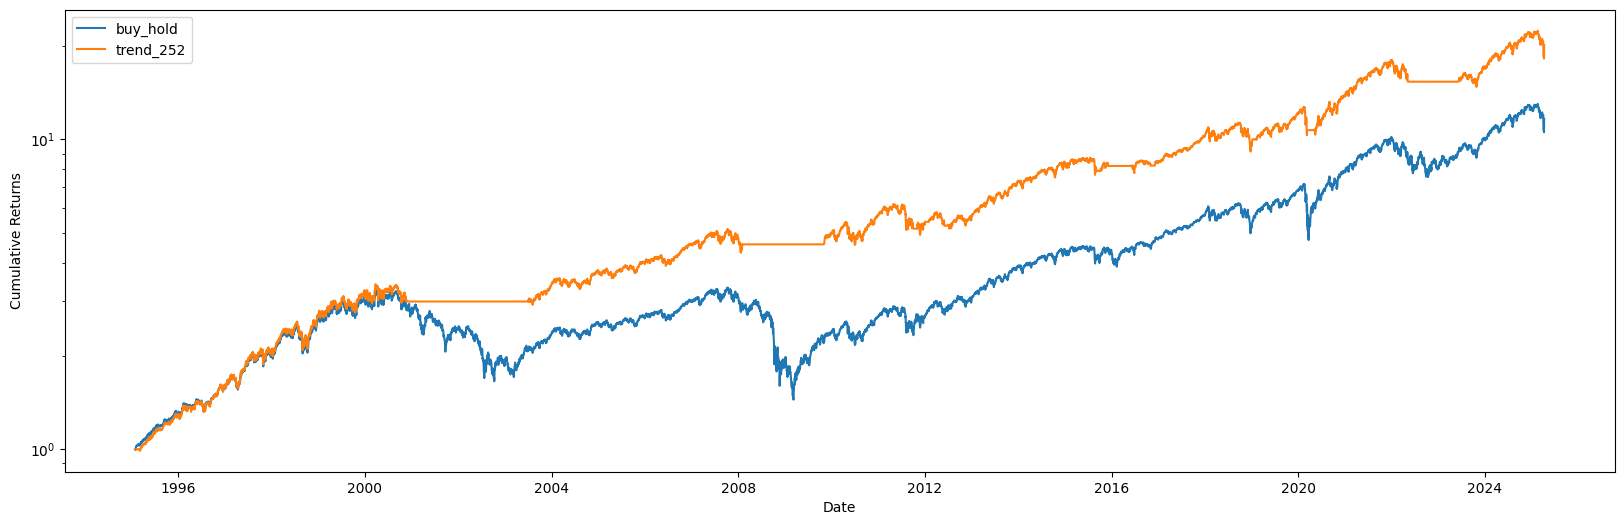

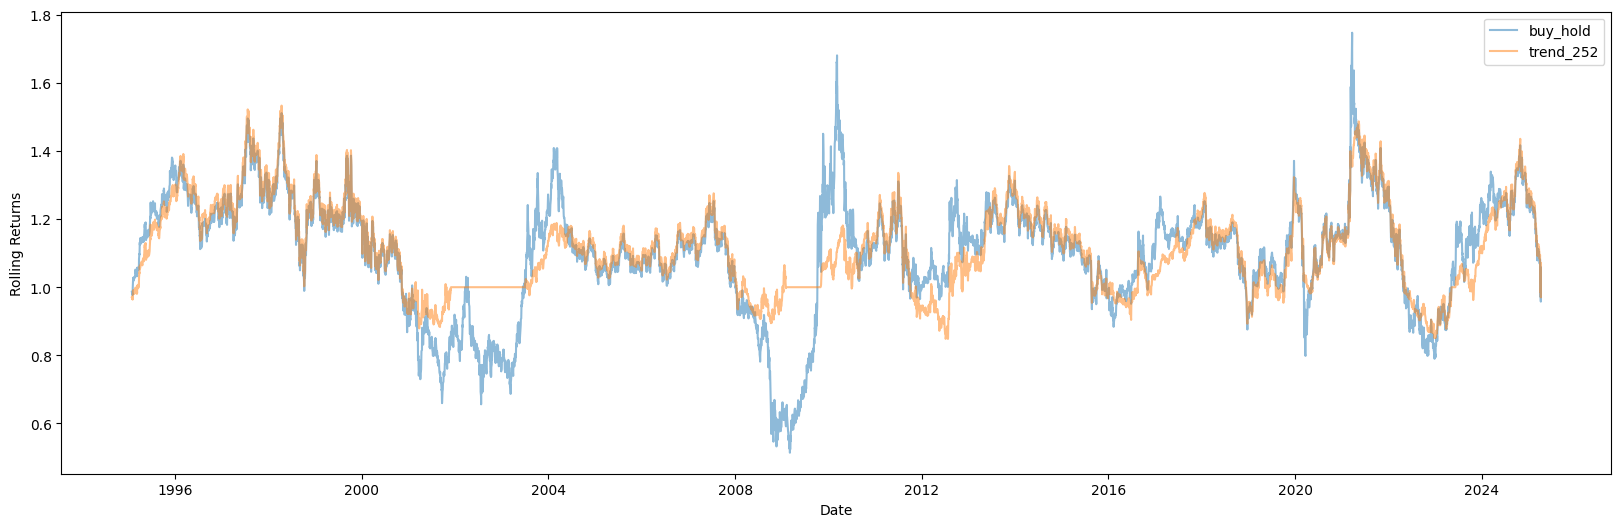

buy_hold
CAGR:           8.48%
Volatility:     19.21%
Sharpe Ratio:   0.44
--------------------------------------------
trend_252
CAGR:           10.46%
Volatility:     13.91%
Sharpe Ratio:   0.75
--------------------------------------------
TLT


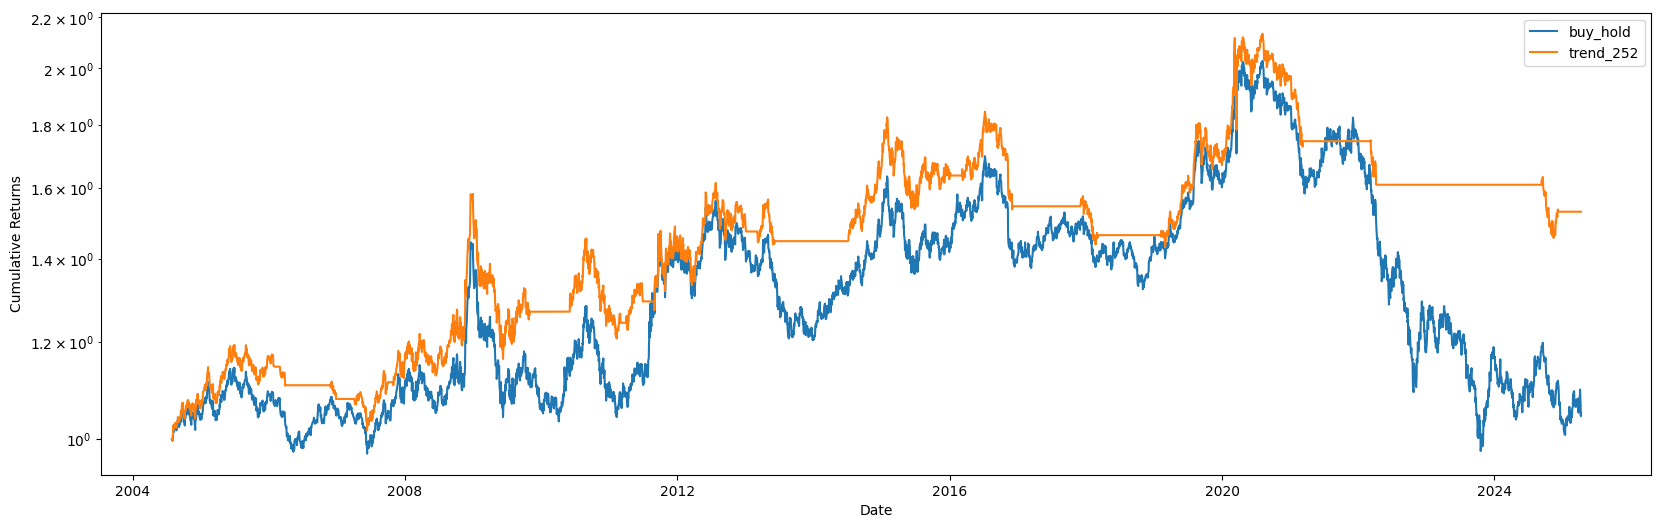

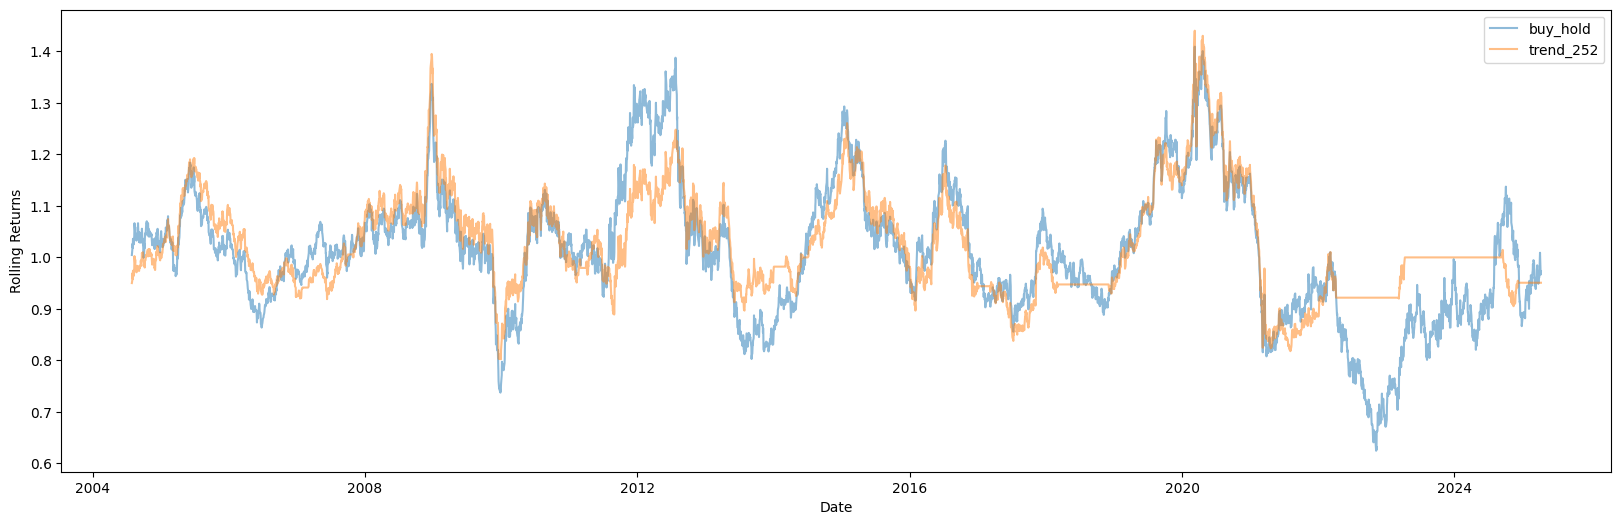

buy_hold
CAGR:           0.24%
Volatility:     14.72%
Sharpe Ratio:   0.02
--------------------------------------------
trend_252
CAGR:           2.08%
Volatility:     11.47%
Sharpe Ratio:   0.18
--------------------------------------------
GLD


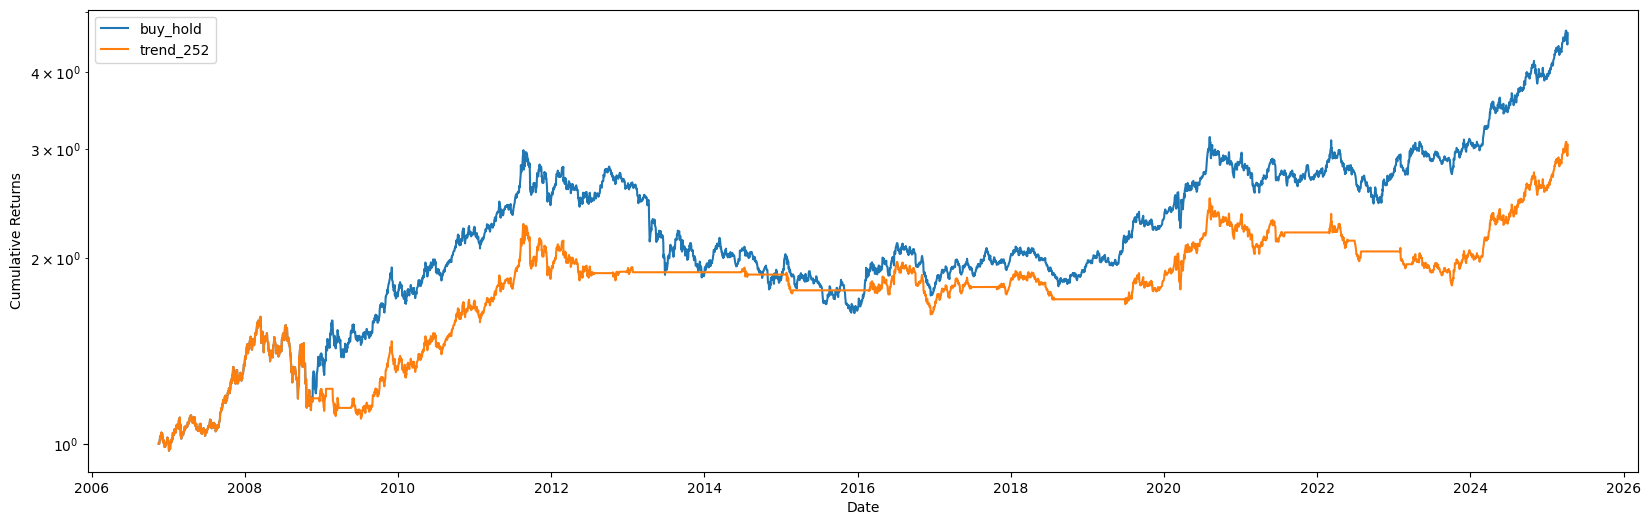

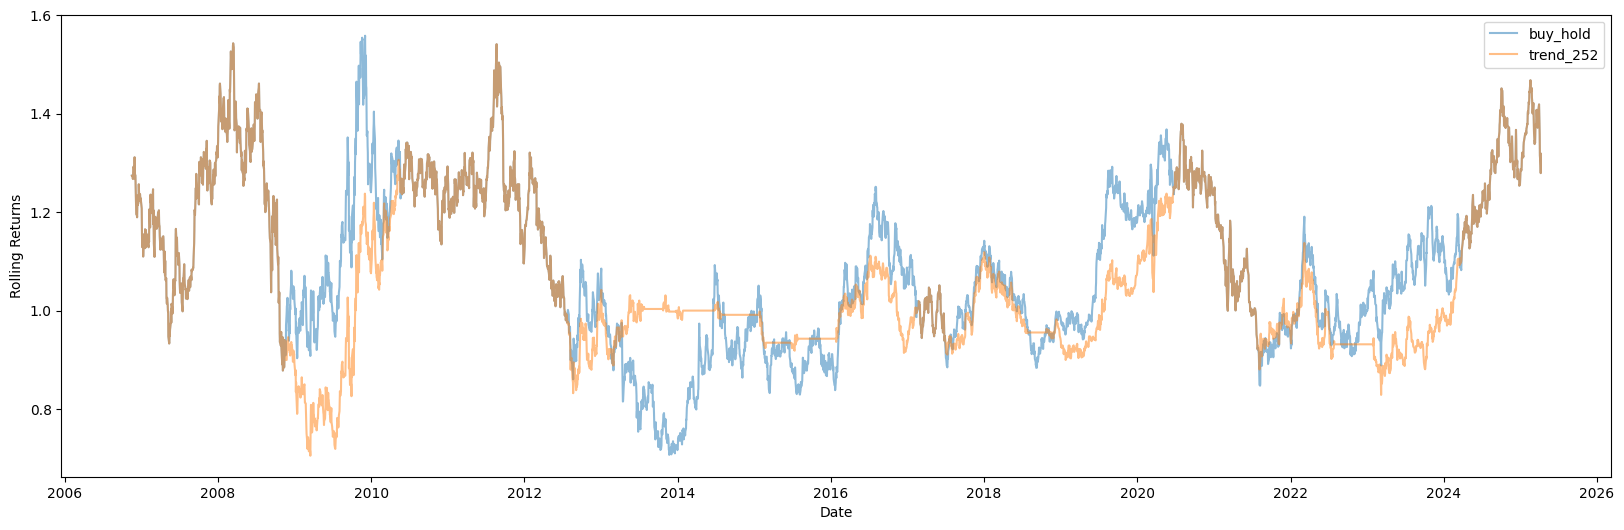

buy_hold
CAGR:           8.69%
Volatility:     17.32%
Sharpe Ratio:   0.50
--------------------------------------------
trend_252
CAGR:           6.26%
Volatility:     14.57%
Sharpe Ratio:   0.43
--------------------------------------------


In [32]:
class TrendFollowingStrategy(BaseStrategy):
    """Trend following strategy with configurable lookback period"""
    
    params = (
        ('lookback_period', 21),  # Default 1-month lookback (21 trading days)
        ('rebalance_period', 21),  # Rebalance period in days
    )

    def __init__(self):
        super().__init__()
        self.returns = bt.indicators.PercentChange(self.data.close, period=self.p.lookback_period)
        self.rebalance_day = 0

        
    def next(self):
        super().next()
        if self.rebalance_day % self.p.rebalance_period == 0:
            current_position = self.getposition(self.data).size
            if self.returns[0] > 0:
                target_position = self.broker.getvalue() / self.data.close[0]
            else:
                target_position = 0
            self._submit_order(self.data._name, target_position - current_position, self.data.close[0])
        self.rebalance_day += 1

combined_returns = pd.DataFrame()
for ticker in tqdm(data['asset_list']):

    print(ticker)
    
    df_data = data[ticker]['data'].copy()

    cols = []
    df_display = pd.DataFrame()
    def compare_returns(df_returns=None, col_name=None, plot=False):
        if col_name is not None:
            if col_name not in cols:
                cols.append(col_name)
            df_display[col_name] = df_returns['returns'].copy() + 1
            df_display[f'{col_name}_cum'] = df_display[col_name].cumprod()
            df_display[f'{col_name}_rolling'] = df_display[col_name].rolling(252).apply(lambda x: x.prod())

            df_display.dropna(inplace=True)
            for col in cols:
                df_display[f'{col}_cum'] = df_display[f'{col}_cum'] / df_display[f'{col}_cum'].iloc[0]

        if plot:
            plt.figure(figsize=(20, 6))
            for col in cols:
                plt.plot(df_display[f'{col}_cum'], label=col)
            plt.legend()
            plt.yscale('log')
            plt.xlabel('Date')
            plt.ylabel('Cumulative Returns')
            plt.show()

            plt.figure(figsize=(20, 6))
            for col in cols:
                plt.plot(df_display[f'{col}_rolling'], label=col, alpha=0.5)
            plt.legend()
            plt.xlabel('Date')
            plt.ylabel('Rolling Returns')
            plt.show()

            for col in cols:
                cagr = (df_display[f'{col}_cum'].iloc[-1] / df_display[f'{col}_cum'].iloc[0]) ** (252 / len(df_display)) - 1
                vol = df_display[f'{col}'].std() * np.sqrt(252)
                sr = cagr / vol

                print(col.replace('returns_', ''))
                print(f'CAGR:           {cagr:.2%}')
                print(f'Volatility:     {vol:.2%}')
                print(f'Sharpe Ratio:   {sr:.2f}')
                print('--------------------------------------------')
        

    compare_returns(df_data[['returns']], 'buy_hold')

    # Trend following
    btr = BackTester({ticker: df_data})
    btr.add_strategy(
        TrendFollowingStrategy, 
        tickers=[ticker], 
        price_data={ticker: df_data}, 
        rebalance_period=rebalance_period, 
        lookback_period=252
    )
    results = btr.backtest()
    returns = results['returns'].copy()
    compare_returns(df_returns=results, col_name=f'trend_252')
    compare_returns(plot=True)

  0%|          | 0/3 [00:00<?, ?it/s]

SPY


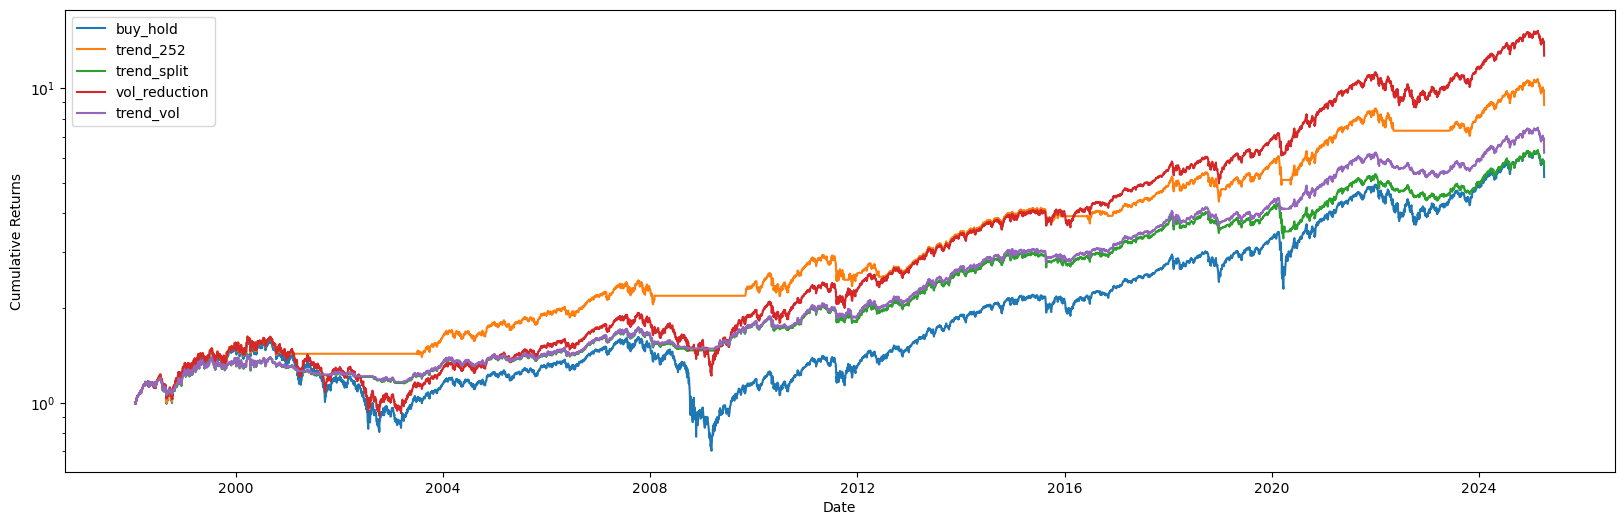

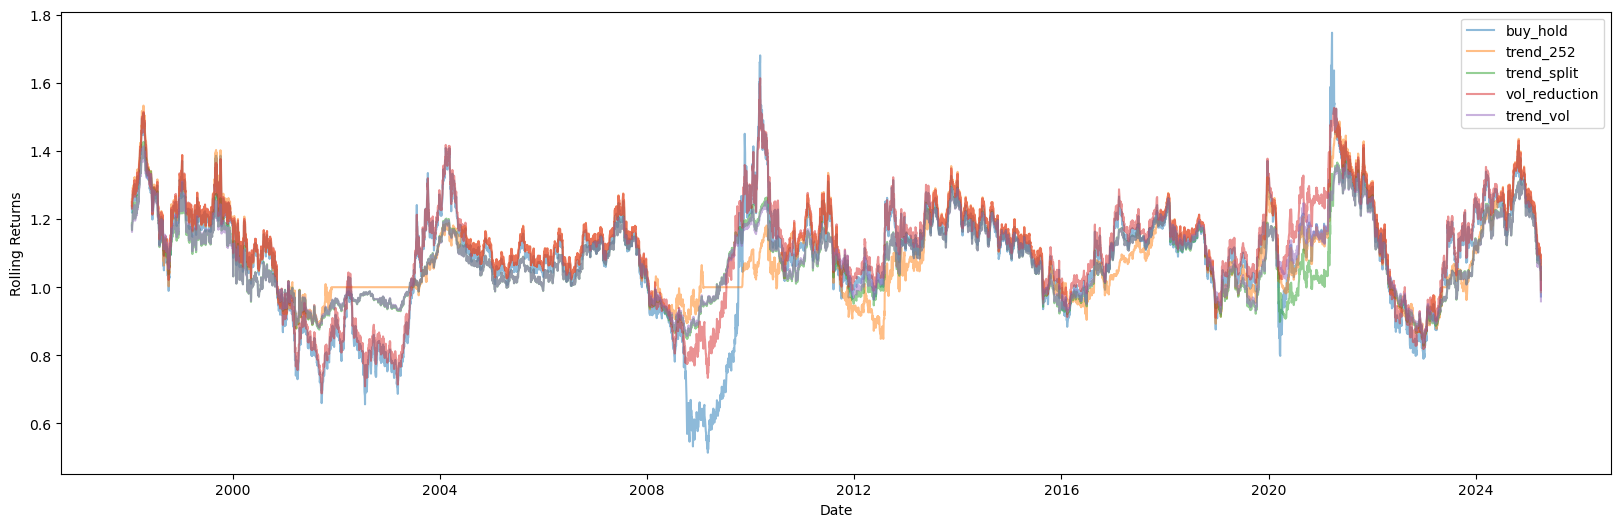

buy_hold
CAGR:           6.27%
Volatility:     19.51%
Sharpe Ratio:   0.32
--------------------------------------------
trend_252
CAGR:           8.35%
Volatility:     13.64%
Sharpe Ratio:   0.61
--------------------------------------------
trend_split
CAGR:           6.57%
Volatility:     11.41%
Sharpe Ratio:   0.58
--------------------------------------------
vol_reduction
CAGR:           9.80%
Volatility:     16.44%
Sharpe Ratio:   0.60
--------------------------------------------
trend_vol
CAGR:           6.97%
Volatility:     10.65%
Sharpe Ratio:   0.65
--------------------------------------------
TLT


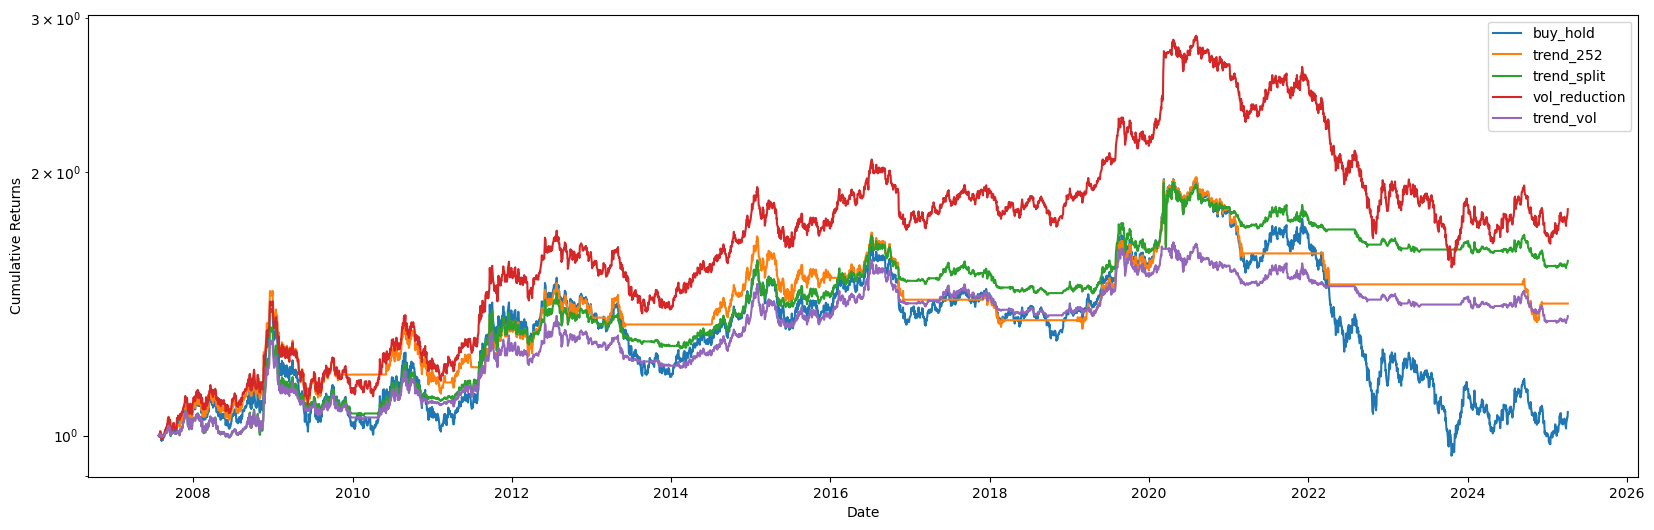

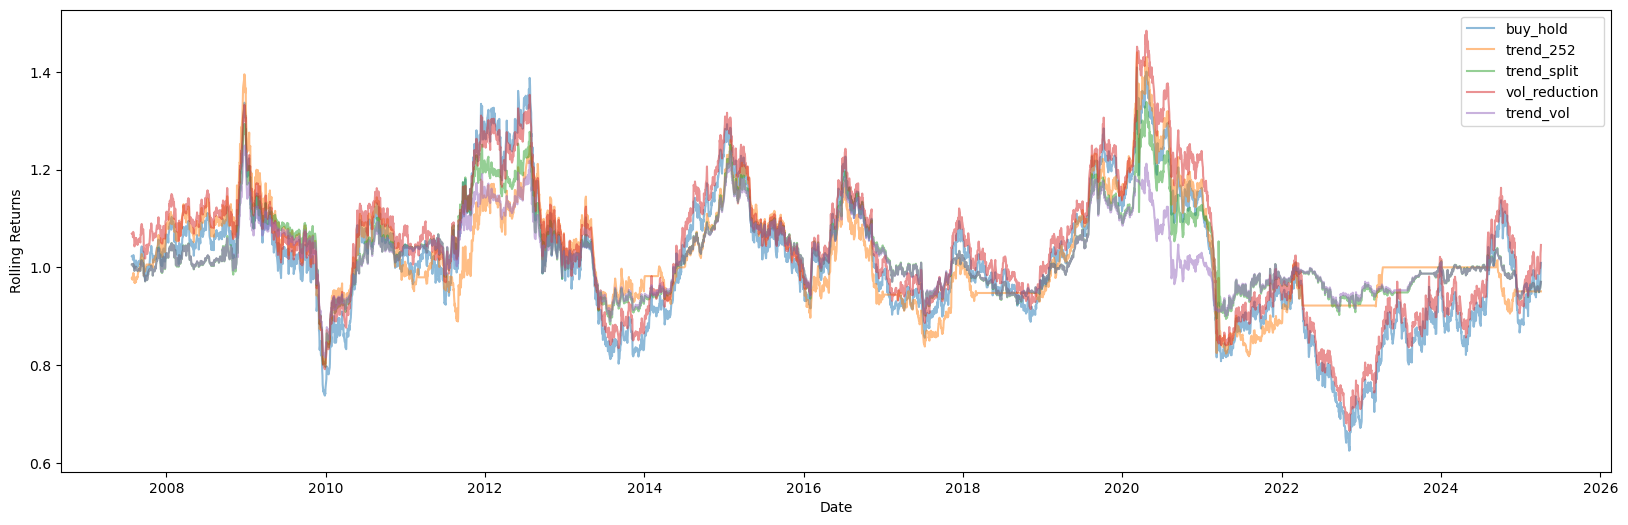

buy_hold
CAGR:           0.35%
Volatility:     15.49%
Sharpe Ratio:   0.02
--------------------------------------------
trend_252
CAGR:           1.98%
Volatility:     12.02%
Sharpe Ratio:   0.17
--------------------------------------------
trend_split
CAGR:           2.63%
Volatility:     10.24%
Sharpe Ratio:   0.26
--------------------------------------------
vol_reduction
CAGR:           3.43%
Volatility:     13.83%
Sharpe Ratio:   0.25
--------------------------------------------
trend_vol
CAGR:           1.79%
Volatility:     8.57%
Sharpe Ratio:   0.21
--------------------------------------------
GLD


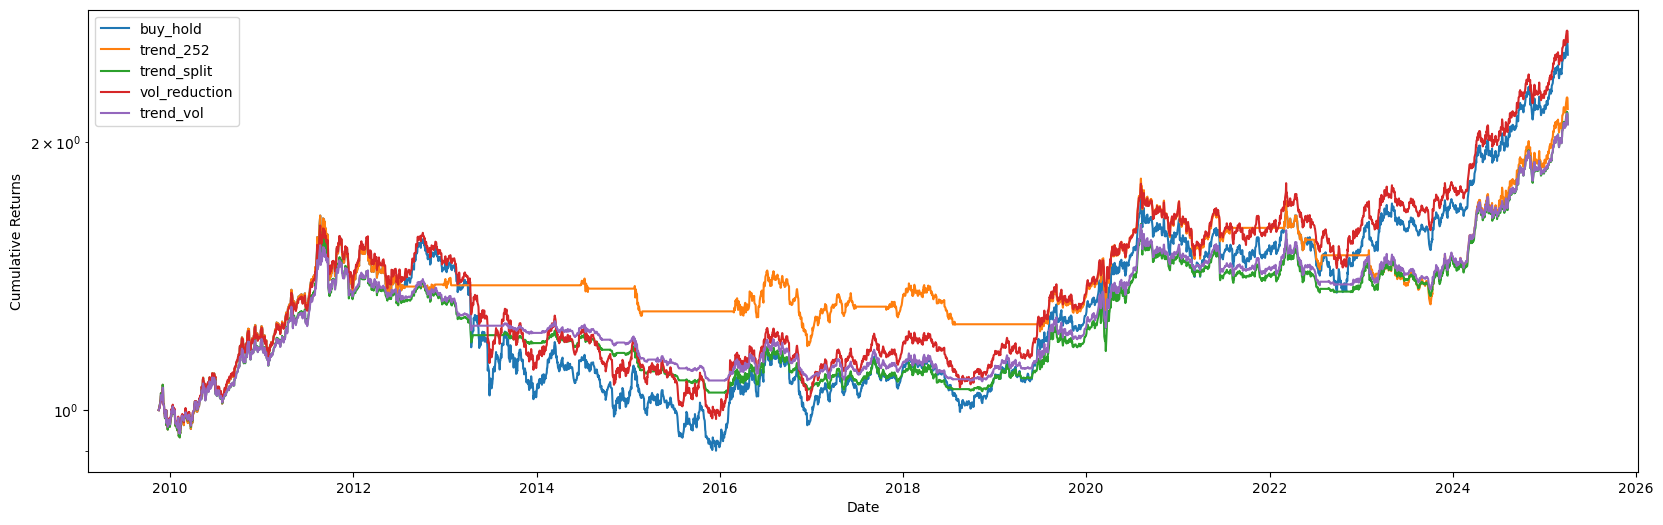

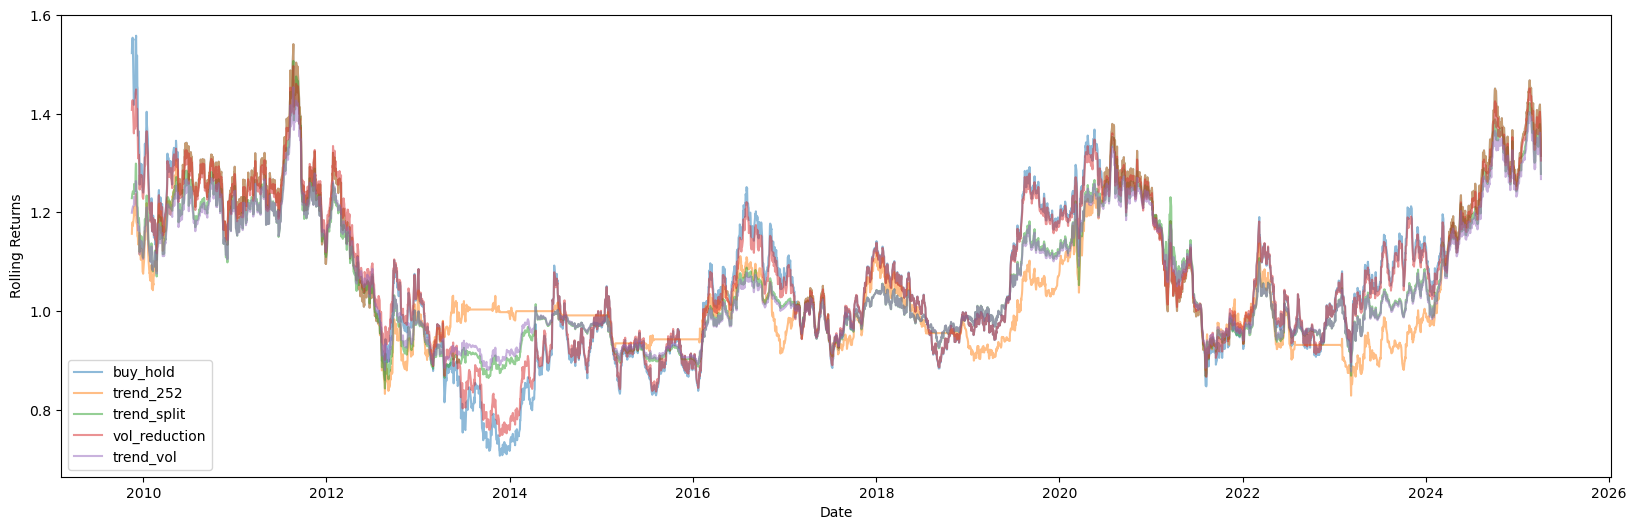

buy_hold
CAGR:           6.16%
Volatility:     15.56%
Sharpe Ratio:   0.40
--------------------------------------------
trend_252
CAGR:           5.20%
Volatility:     12.45%
Sharpe Ratio:   0.42
--------------------------------------------
trend_split
CAGR:           4.94%
Volatility:     11.32%
Sharpe Ratio:   0.44
--------------------------------------------
vol_reduction
CAGR:           6.39%
Volatility:     14.03%
Sharpe Ratio:   0.46
--------------------------------------------
trend_vol
CAGR:           4.92%
Volatility:     10.13%
Sharpe Ratio:   0.49
--------------------------------------------


,SPY,TLT,GLD
Date,,,
1998-01-21,0.992088,NaN,NaN
1998-01-22,0.991264,NaN,NaN
1998-01-23,0.998558,NaN,NaN
1998-01-26,0.999358,NaN,NaN
1998-01-27,1.009955,NaN,NaN
...,...,...,...
2025-03-31,1.006508,1.003836,1.013796
2025-04-01,1.002739,1.001975,0.998099
2025-04-02,1.006137,1.001140,1.001972


In [ ]:
class TrendFollowingStrategy(BaseStrategy):
    """Trend following strategy with configurable lookback period"""
    
    params = (
        ('lookback_period', 21),  # Default 1-month lookback (21 trading days)
        ('rebalance_period', 21),  # Rebalance period in days
    )

    def __init__(self):
        super().__init__()
        self.returns = bt.indicators.PercentChange(self.data.close, period=self.p.lookback_period)
        self.rebalance_day = 0

        
    def next(self):
        super().next()
        if self.rebalance_day % self.p.rebalance_period == 0:
            current_position = self.getposition(self.data).size
            if self.returns[0] > 0:
                target_position = self.broker.getvalue() / self.data.close[0]
            else:
                target_position = 0
            self._submit_order(self.data._name, target_position - current_position, self.data.close[0])
        self.rebalance_day += 1


class TrendSplitStrategy(BaseStrategy):
    """Trend following strategy with configurable lookback period"""
    
    params = (
        ('lookback_periods', [21, 252]),
        ('rebalance_period', 21),  # Rebalance period in days
    )

    def __init__(self):
        super().__init__()
        self.returns = dict()
        for period in self.p.lookback_periods:
            self.returns[period] = bt.indicators.PercentChange(self.data.close, period=period)
        self.weight = 1 / len(self.p.lookback_periods)
        self.rebalance_day = 0

        
    def next(self):
        super().next()
        if self.rebalance_day % self.p.rebalance_period == 0:
            current_position = self.getposition(self.data).size
            target_size = 0.0        
            for period in self.p.lookback_periods:
                if self.returns[period][0] > 0:
                    target_size += self.weight
            target_position = target_size * (self.broker.getvalue() / self.data.close[0])
            self._submit_order(self.data._name, target_position - current_position, self.data.close[0])
            
        self.rebalance_day += 1



class VolStrategy(BaseStrategy):
    """Trend following strategy with configurable lookback period"""

    params = (
        ('rebalance_period', 21),  # Rebalance period in days
        ('df_vol', pd.DataFrame()),
    )

    def __init__(self):
        super().__init__()
        self.rebalance_day = 0
        self.df_vol = self.p.df_vol
        if 'var_forward_scaled' not in self.df_vol.columns:
            raise ValueError("df_vol must have a column 'var_forward_scaled'")

        
    def next(self):
        super().next()
        if self.rebalance_day % self.p.rebalance_period == 0:
            current_position = self.getposition(self.data).size
            target_size = 1.0
            current_date = self.datetime.date()
            var_scaled = self.df_vol.loc[self.df_vol.index == pd.to_datetime(current_date), 'var_forward_scaled'].values[0]
            target_size = 1 - var_scaled
            target_position = target_size * (self.broker.getvalue() / self.data.close[0])
            self._submit_order(self.data._name, target_position - current_position, self.data.close[0])
        self.rebalance_day += 1



class TrendVolStrategy(BaseStrategy):
    """Trend following strategy with configurable lookback period"""
    
    params = (
        ('lookback_periods', [21, 252]),  # Default 1-month lookback (21 trading days)
        ('rebalance_period', 21),  # Rebalance period in days
        ('df_vol', pd.DataFrame()),
    )

    def __init__(self):
        super().__init__()
        self.returns = dict()
        for period in self.p.lookback_periods:
            self.returns[period] = bt.indicators.PercentChange(self.data.close, period=period)
        self.weight = 1 / len(self.p.lookback_periods)
        self.rebalance_day = 0
        self.df_vol = self.p.df_vol
        if 'var_forward_scaled' not in self.df_vol.columns:
            raise ValueError("df_vol must have a column 'var_forward_scaled'")

        
    def next(self):
        super().next()
        if self.rebalance_day % self.p.rebalance_period == 0:
            current_position = self.getposition(self.data).size
            target_size = 0.0        
            for period in self.p.lookback_periods:
                if self.returns[period][0] > 0:
                    target_size += self.weight

            current_date = self.datetime.date()
            var_scaled = self.df_vol.loc[self.df_vol.index == pd.to_datetime(current_date), 'var_forward_scaled'].values[0]
            target_size *= np.clip(1 - var_scaled, 0, 1)
        
            target_position = target_size * ((self.broker.getvalue() / self.data.close[0]))
            self._submit_order(self.data._name, target_position - current_position, self.data.close[0])
        self.rebalance_day += 1




combined_returns = pd.DataFrame()
for ticker in tqdm(data['asset_list']):

    print(ticker)
    
    df_data = data[ticker]['data'].copy()

    cols = []
    df_display = pd.DataFrame()
    def compare_returns(df_returns=None, col_name=None, plot=False):
        if col_name is not None:
            if col_name not in cols:
                cols.append(col_name)
            df_display[col_name] = df_returns['returns'].copy() + 1
            df_display[f'{col_name}_cum'] = df_display[col_name].cumprod()
            df_display[f'{col_name}_rolling'] = df_display[col_name].rolling(252).apply(lambda x: x.prod())

            df_display.dropna(inplace=True)
            for col in cols:
                df_display[f'{col}_cum'] = df_display[f'{col}_cum'] / df_display[f'{col}_cum'].iloc[0]

        if plot:
            plt.figure(figsize=(20, 6))
            for col in cols:
                plt.plot(df_display[f'{col}_cum'], label=col)
            plt.legend()
            plt.yscale('log')
            plt.xlabel('Date')
            plt.ylabel('Cumulative Returns')
            plt.show()

            plt.figure(figsize=(20, 6))
            for col in cols:
                plt.plot(df_display[f'{col}_rolling'], label=col, alpha=0.5)
            plt.legend()
            plt.xlabel('Date')
            plt.ylabel('Rolling Returns')
            plt.show()

            for col in cols:
                cagr = (df_display[f'{col}_cum'].iloc[-1] / df_display[f'{col}_cum'].iloc[0]) ** (252 / len(df_display)) - 1
                vol = df_display[f'{col}'].std() * np.sqrt(252)
                sr = cagr / vol

                print(col.replace('returns_', ''))
                print(f'CAGR:           {cagr:.2%}')
                print(f'Volatility:     {vol:.2%}')
                print(f'Sharpe Ratio:   {sr:.2f}')
                print('--------------------------------------------')
        

    compare_returns(df_data[['returns']], 'buy_hold')

    # Trend following
    btr = BackTester({ticker: df_data})
    btr.add_strategy(
        TrendFollowingStrategy, 
        tickers=[ticker], 
        price_data={ticker: df_data}, 
        rebalance_period=rebalance_period, 
        lookback_period=252
    )
    results = btr.backtest()
    returns = results['returns'].copy()
    compare_returns(df_returns=results, col_name=f'trend_252')



    # Trend split
    btr = BackTester({ticker: df_data})
    btr.add_strategy(
        TrendSplitStrategy, 
        tickers=[ticker], 
        price_data={ticker: df_data}, 
        rebalance_period=rebalance_period, 
        lookback_periods=lookback_periods
    )
    results = btr.backtest()
    returns = results['returns'].copy()
    compare_returns(df_returns=results, col_name=f'trend_split')

    

    # calculate vol
    
    # Vol Reduction
    btr = BackTester({ticker: df_data})
    btr.add_strategy(
        VolStrategy, 
        tickers=[ticker], 
        price_data={ticker: df_data}, 
        rebalance_period=rebalance_period, 
        df_vol=df_data[['var_forward_scaled']]
    )
    results = btr.backtest()
    returns = results['returns'].copy()
    compare_returns(df_returns=results, col_name=f'vol_reduction')

    # Trend Vol
    btr = BackTester({ticker: df_data})
    btr.add_strategy(
        TrendVolStrategy, 
        tickers=[ticker], 
        price_data={ticker: df_data}, 
        rebalance_period=rebalance_period, 
        df_vol=df_data[['var_forward_scaled']], 
        lookback_periods=lookback_periods,
    )
    results = btr.backtest()
    returns = results['returns'].copy()
    compare_returns(df_returns=results, col_name=f'trend_vol')


    compare_returns(plot=True)

    combined_returns[ticker] = df_display['trend_vol']



display(combined_returns)
    



## HRP allocation

CAGR: 4.82%
Volatility: 5.29%
Sharpe Ratio: 0.91
Max Drawdown: -8.95%


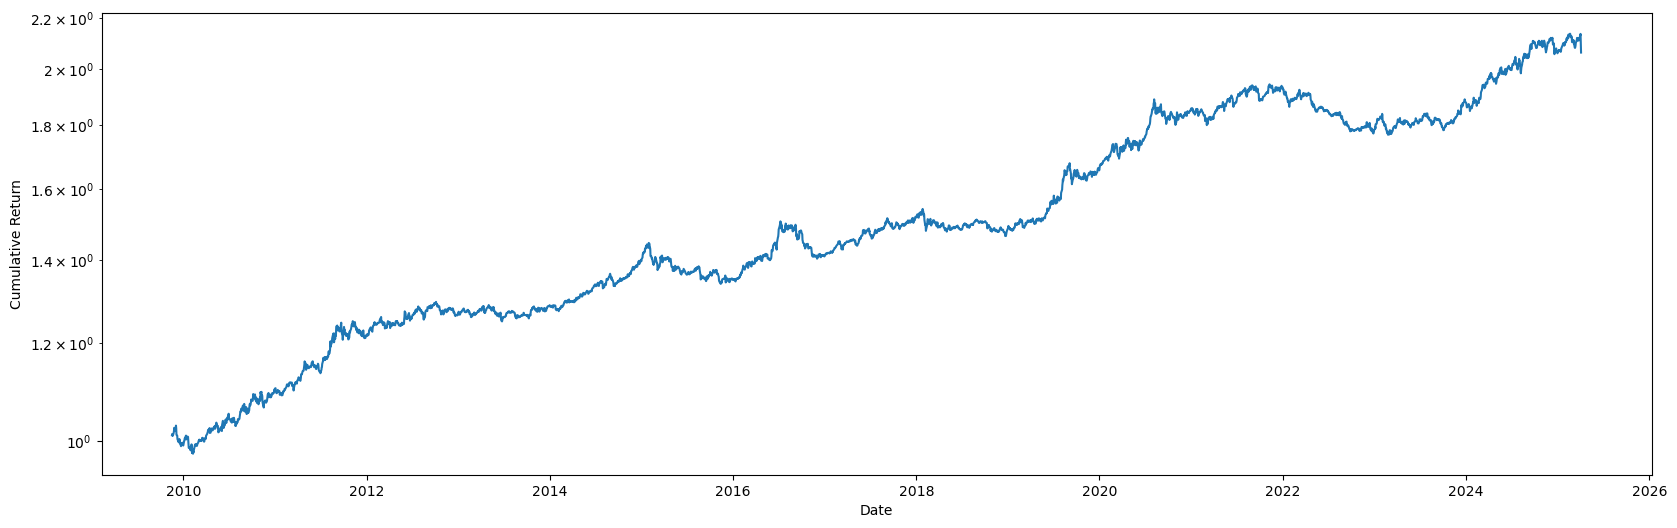

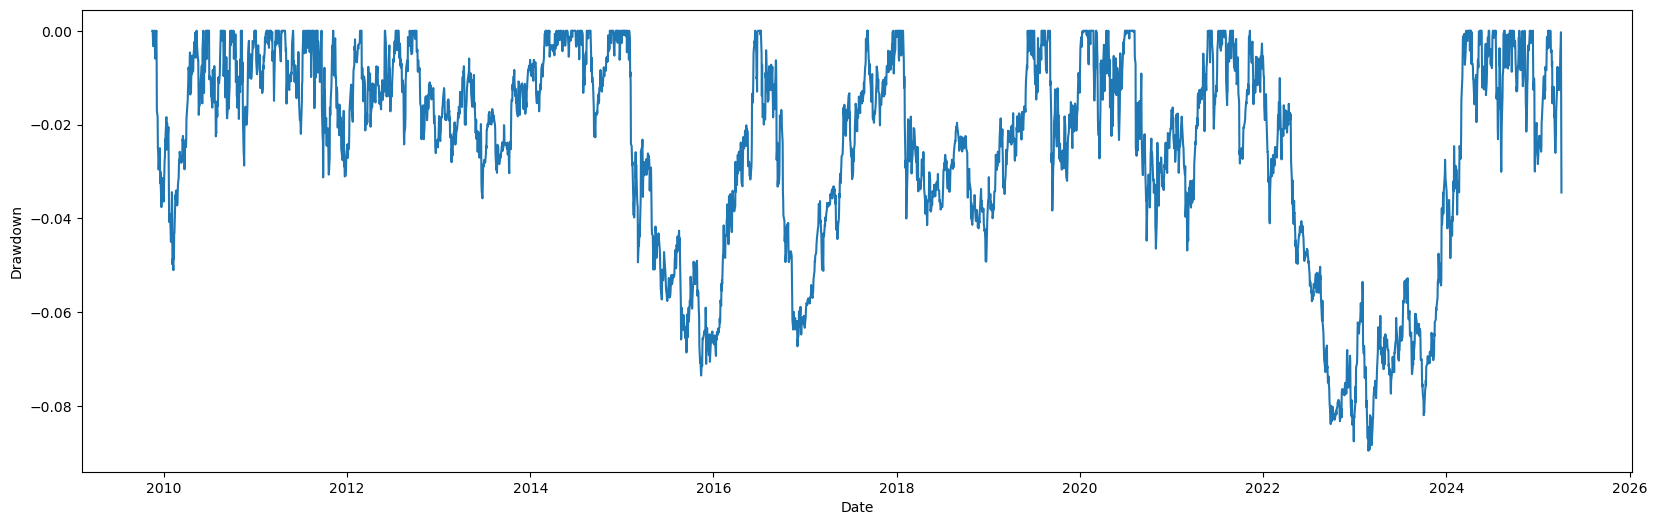

In [ ]:
from pypfopt import HRPOpt

def hierarchical_risk_parity_allocation(asset_dfs):
    """
    Perform Hierarchical Risk Parity (HRP) asset allocation given multiple dataframes of asset returns.

    Parameters:
    asset_dfs (list of pd.DataFrame): List of dataframes, each containing 'dates' and 'returns' columns.

    Returns:
    dict: Asset allocation weights with generated asset names as keys.
    """
    processed_series = []
    
    # Process each asset dataframe to create return series with unique names
    for ticker in asset_dfs:
        df = asset_dfs[ticker].copy()
        # df['date'] = pd.to_datetime(df['date'])
        # df.set_index('date', inplace=True)
        df = df[~df.index.duplicated(keep='first')]  # Remove duplicate dates
        asset_name = ticker
        processed_series.append(df['returns'].rename(asset_name))
    
    # Combine all series into a single dataframe with inner join
    combined_df = pd.concat(processed_series, axis=1, join='inner')

    # display(combined_df)
    
    if combined_df.empty:
        raise ValueError("No common dates found across all assets")
    
    # Calculate HRP weights
    hrp = HRPOpt(combined_df)
    hrp_weights = hrp.optimize()
    
    return hrp_weights

asset_dfs = dict()
for ticker in data['asset_list']:
    df = pd.DataFrame()
    df['returns'] = combined_returns[ticker].copy()
    df.dropna(inplace=True)
    asset_dfs[ticker] = df

hrp_weights = hierarchical_risk_parity_allocation(asset_dfs)


for ticker in data['asset_list']:
    data[ticker]['hrp_weight'] = hrp_weights[ticker]



combined_returns.dropna(inplace=True)
combined_ret_arr = []
for i, r in combined_returns.iterrows():
    combined_ret = 0
    for ticker in data['asset_list']:
        combined_ret += r[ticker] * hrp_weights[ticker]
    combined_ret_arr.append(combined_ret)

combined_returns['combined_ret'] = combined_ret_arr
combined_returns['combined_ret_cum'] = (combined_returns['combined_ret']).cumprod()

cagr = (combined_returns['combined_ret_cum'][-1] ** (252 / len(combined_returns))) - 1
print(f"CAGR: {cagr:.2%}")
vol = combined_returns['combined_ret'].std() * np.sqrt(252)
print(f"Volatility: {vol:.2%}")
sharpe = cagr / vol
print(f"Sharpe Ratio: {sharpe:.2f}")
drawdown = combined_returns['combined_ret_cum'] / np.maximum.accumulate(combined_returns['combined_ret_cum']) - 1
max_drawdown = np.min(drawdown)
print(f"Max Drawdown: {max_drawdown:.2%}")

plt.figure(figsize=(20, 6))
plt.plot(combined_returns.index, combined_returns['combined_ret_cum'])
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.yscale('log')
plt.show()

plt.figure(figsize=(20, 6))
plt.plot(combined_returns.index, drawdown)
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.show()

# for ticker in data['asset_list']:
#     df = data[ticker]['data'].copy()
#      hrp_weights[ticker]

## Forecast Volatility

(8080, 2)


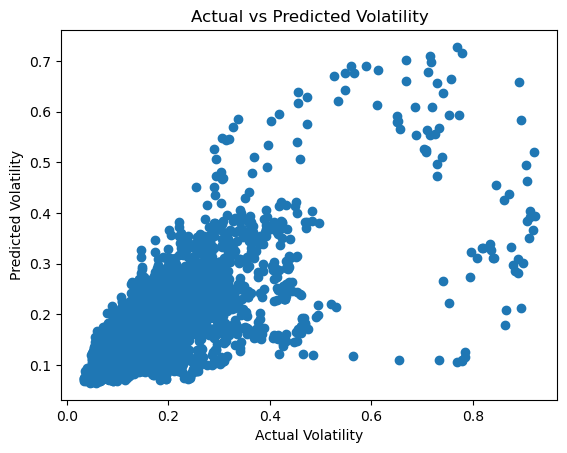

(5687, 1)


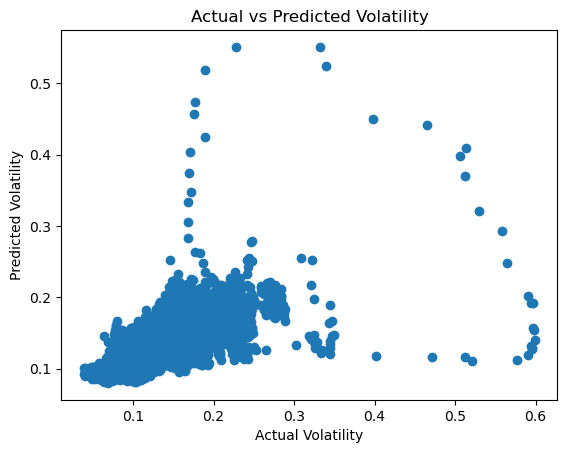

(4216, 2)


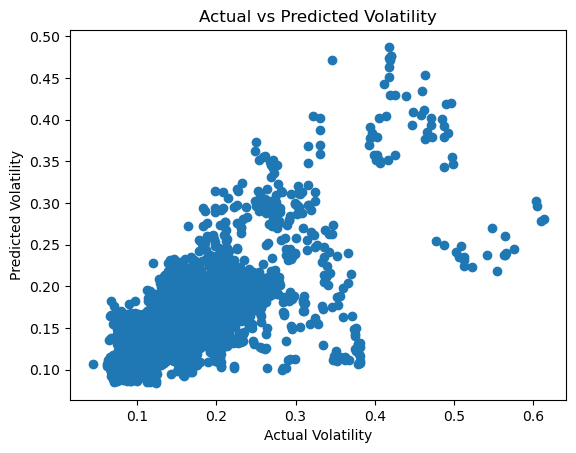

In [ ]:

target_positions = {}
for ticker in data['asset_list']:
    # display(data[ticker]['data'])

    df = data[ticker]['data'].copy()   
    
    df_train = df.dropna().copy()
    y = df_train['vol_forward'].to_numpy()
    X = []
    if 'vix' in df:
        X .append(df_train['vix'].to_numpy().reshape(-1, 1))
    if 'ATR' in df:
        X.append(df_train['ATR'].to_numpy().reshape(-1, 1))
    X = np.concatenate(X, axis=1)
    print(X.shape)
       
    model = LinearRegression()
    model.fit(X, y)

    y_pred = model.predict(X)
    plt.scatter(y, y_pred)
    plt.xlabel('Actual Volatility')
    plt.ylabel('Predicted Volatility')
    plt.title('Actual vs Predicted Volatility')
    plt.show()

    data[ticker]['vol_model'] = model




## Trade strategy

In [ ]:
sum_weights = 0
for ticker in data['asset_list']:

    df = data[ticker]['data'].copy()

    vol_input = []
    if 'vix' in df:
        vix = df['vix'].to_list()[-1]
        vol_input.append(vix)
    if 'ATR' in df:
        atr = df['ATR'].to_list()[-1]
        vol_input.append(atr)
    
    vol_input =  np.array([vol_input])
    # print(vol_input.shape)
    forward_vol = data[ticker]['vol_model'].predict(vol_input)[0]
    forward_var = forward_vol ** 2
    forward_var_scaled = data[ticker]['var_scaler'].transform(np.array([forward_var]).reshape(-1, 1))[0][0]
    # print(forward_var_scaled)

    
    weight = 1 / len(lookback_periods)
    for period in lookback_periods:
        df[f'ret_{period}'] = calculate_returns(df, period)
        ret = df[f'ret_{period}'].to_list()[-1]
        if ret > 0:
            target_position = 1 * weight
    target_position *= (1 - forward_var_scaled)


    weight = data[ticker]['hrp_weight'] * target_position
    sum_weights += weight
    num_shares = int((weight * capital) / df['close'].to_list()[-1])

    print('-----------------------------------')
    print(f'ticker: {ticker}, date: {df.index[-1]}')
    print(f'num_shares: {num_shares}')

df = data['SHV']['data'].copy()
num_shares = int((1 - sum_weights) * capital / df['close'].to_list()[-1])
num_shares = max(num_shares, 0)
print('-----------------------------------')
print(f'ticker: SHV, date: {df.index[-1]}')
print(f'num_shares: {num_shares}')

-----------------------------------
ticker: SPY, date: 2025-04-04 00:00:00
num_shares: 6
-----------------------------------
ticker: TLT, date: 2025-04-04 00:00:00
num_shares: 56
-----------------------------------
ticker: GLD, date: 2025-04-04 00:00:00
num_shares: 11
-----------------------------------
ticker: SHV, date: 2025-04-04 00:00:00
num_shares: 465


# END